In [1]:
import jets
import jets.metrics as metrics

In [ ]:
config = {
    'exp_name': 'test',
    'visual': {
        'fields': ['q', 'v'],
        'spectra': ['z', 'e'],
        'means' : ['z_mean', 'e_mean'],
    },
    'atmosphere': {
        'n_grid': 256, 
        'params': {
            'initial': 'zero', 
            'forcing': 'norm',
            'p': 2,
            'nu': 4e-8, 
            'r': 0.01,
            'epsilon': 1.0,
            'kf': 16,
            'dkf': 2,
        }
    },
    'integrator': {
        'method': 'rk4',
        'interval': 1,
        'n_points': 100,
    },
}

model = jets.Driver()
model.setup(**config)
model.start()
print(model.descript())

def check_saturation(climate):
    if len(climate['t'])<=2:
        return False, None
    t, z_mean = climate['t'][1::], climate['z_mean'][1::]
    z_params, z_found = metrics.find_saturation(t, z_mean, crit=1)
    if z_found:
        metrics.plot_saturation(t, z_mean, z_params, 'z_mean')
        print(f"found t_sat: {z_found}")
        return True, z_params
    else:
        return False, None

[meta]
model = qgc-1
type = quasi-geostrophic
coord = cartesian
approach = spectral-1

[atmosphere]
initial = zero
forcing = norm
initial_seed = 42
forcing_seed = 42
p = 2
beta = 0.0
nu = 4e-08
r = 0.01
kappa = 0.0
epsilon = 1.0
kf = 16
dkf = 2
sigma = 1.0
dt = 0.0001

[integrator]
method = rk4
interval = 1
n_points = 100




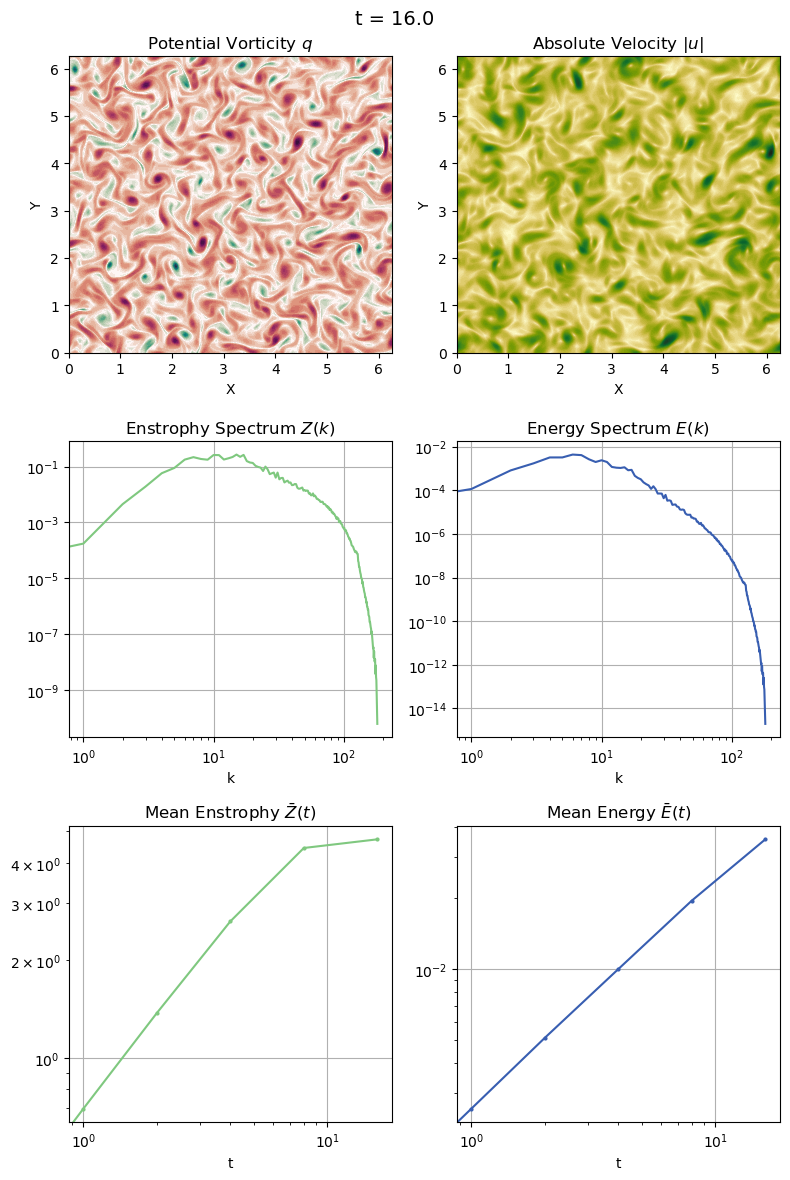

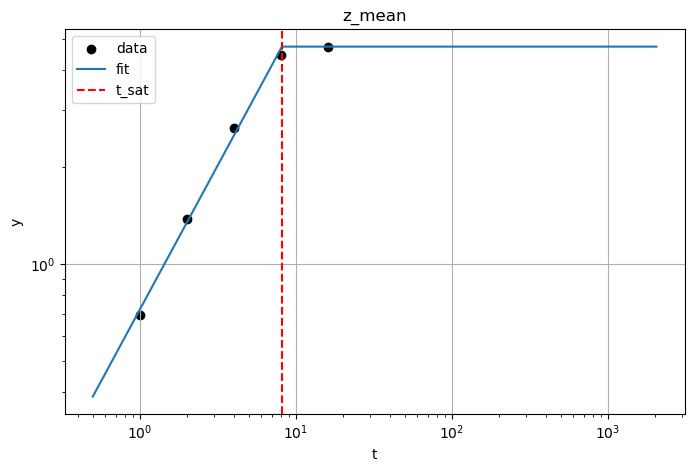

 50%|█████     | 5/10 [03:21<03:21, 40.38s/it]

z_mean:
A = 4.72e+00
alpha = 0.90
t_sat = 8
found t_sat: True
{'alpha': np.float64(0.8951880722575629), 'A': np.float64(4.722659473210501), 't_sat': np.float64(8.15123488994352)}


In [ ]:
data = model.run(10, show=True, logtime=True, tau=2, metrics=check_saturation)
print(data)